#***Can frequency of waste collection affected by Number of the people in household, distance to waste collection point, Area type?***

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

print("Libraries imported successfully.")

df = pd.read_excel('Final_Cleaned_Waste_Survey_185.xlsx')

print("Excel file loaded successfully.")


Libraries imported successfully.
Excel file loaded successfully.


In [ ]:
#to check column names in excel
print("Column names:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

Column names:
0 : Q1. Age
1 : Q2. Province
2 : Q3. District
3 : Q4. Local Authority
4 : Q5. Area Type
5 : Q6. Place Type
6 : Q7. No. of People
7 : Q8. Land Size
8 : Q9. Waste Storage Method
9 : Q10. Bag Size
10 : Q11. Bin Size
11 : Q12a. Food Waste (bags)
12 : Q12b. Garden Waste (bags)
13 : Q12c. Plastic (bags)
14 : Q12d. Paper (bags)
15 : Q12e. Glass (bags)
16 : Q12f. Metal (bags)
17 : Q12g. E-Waste (bags)
18 : Q12h. Textile (bags)
19 : Q12i. Rubber (bags)
20 : Q12j. Coconut (bags)
21 : Q12k. Packaging (bags)
22 : Q12l. Medical (bags)
23 : Q12m. Other (bags)
24 : Q13a. Food Waste (bins)
25 : Q13b. Garden Waste (bins)
26 : Q13c. Plastic (bins)
27 : Q13d. Paper (bins)
28 : Q13e. Glass (bins)
29 : Q13f. Metal (bins)
30 : Q13g. E-Waste (bins)
31 : Q13h. Textile (bins)
32 : Q13i. Rubber (bins)
33 : Q13j. Coconut (bins)
34 : Q13k. Packaging (bins)
35 : Q13l. Medical (bins)
36 : Q13m. Other (bins)
37 : Q14. Separate Recyclables?
38 : Q15. Recycle Waste?
39 : Q16. How Recycle?
40 : Q17. Incom

In [ ]:
#to examine what included in dependent variable (This is dependent variable)
df['Q20. Collection Frequency'].value_counts(dropna=False)

,count
Q20. Collection Frequency,
Weekly,73
Twice a week,62
Once every two weeks,10
Daily,10
Monthly,9
No,6
Other: __________,5
Never,3
No collection,2


In [ ]:
#Standardize the "no collection" responses
df['Frequency_Clean'] = df['Q20. Collection Frequency'].astype(str).str.strip()

In [ ]:
#to convert differnt no options into no_collection
no_collection = [
    'No',
    'Never',
    'No collection',
    'Do not collect',
    'Never collect',
    'Not come to collect',
    'no proper collecting method',
    'Not collecting'
]

df.loc[df['Frequency_Clean'].isin(no_collection), 'Frequency_Clean'] = 'No collection'

In [ ]:
#to check the changes in no_collection
print(df['Frequency_Clean'].value_counts(dropna=False))

Frequency_Clean
Weekly                  73
Twice a week            62
No collection           16
Daily                   10
Once every two weeks    10
Monthly                  9
Other: __________        5
Name: count, dtype: int64


In [ ]:
#change other into NaN (missing value)
df.loc[
    df['Frequency_Clean'].str.contains('Other', case=False, na=False),
    'Frequency_Clean'
] = np.nan

In [ ]:
#to convert frequencies into numbers
frequency_mapping = {
    'Daily': 7,
    'Twice a week': 2,
    'Weekly': 1,
    'Once every two weeks': 0.5,
    'Monthly': 1/4,
    'No collection': 0
}

df['Collection_Frequency'] = df['Frequency_Clean'].map(frequency_mapping)

In [ ]:
#to check the convertion upto row 20
print(df[
    ['Q20. Collection Frequency', 'Frequency_Clean', 'Collection_Frequency']
].head(20))

   Q20. Collection Frequency    Frequency_Clean  Collection_Frequency
0                     Weekly             Weekly                   1.0
1          Other: __________  Other: __________                   NaN
2                     Weekly             Weekly                   1.0
3          Other: __________  Other: __________                   NaN
4          Other: __________  Other: __________                   NaN
5                     Weekly             Weekly                   1.0
6          Other: __________  Other: __________                   NaN
7                     Weekly             Weekly                   1.0
8               Twice a week       Twice a week                   2.0
9               Twice a week       Twice a week                   2.0
10                    Weekly             Weekly                   1.0
11              Twice a week       Twice a week                   2.0
12              Twice a week       Twice a week                   2.0
13                  

In [ ]:
#display the final dependent variable results
print(df['Collection_Frequency'].value_counts(dropna=False).sort_index())

Collection_Frequency
0.00    16
0.25     9
0.50    10
1.00    73
2.00    62
7.00    10
NaN      5
Name: count, dtype: int64


In [ ]:
selected_columns = [
    'Q7. No. of People',
    'Q19. Distance to Collection Point',
    'Q5. Area Type'
]

for col in selected_columns:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print(df[col].value_counts(dropna=False))


Q7. No. of People
Q7. No. of People
3 - 4 persons          110
5 - 6 persons           60
1 - 2 persons            7
More than 8 persons      4
7 - 8 persons            4
Name: count, dtype: int64

Q19. Distance to Collection Point
Q19. Distance to Collection Point
More than 2 km                   71
1–2 km                           46
No collection point available    23
Less than 100 m                  18
100–499 m                        18
500–999 m                         9
Name: count, dtype: int64

Q5. Area Type
Q5. Area Type
Semi-urban (අර්ධ නාගරික)    84
Urban (නාගරික)              61
Rural (ග්‍රාමීය)            40
Name: count, dtype: int64


In [ ]:
# Select variables for regression
reg_df = df[
    [
        'Collection_Frequency',
        'Q7. No. of People',
        'Q19. Distance to Collection Point',
        'Q5. Area Type'
    ]
].copy()

# Remove rows with missing values
reg_df = reg_df.dropna()

print("Rows available for regression:", len(reg_df))
print(reg_df.head())

Rows available for regression: 180
   Collection_Frequency Q7. No. of People Q19. Distance to Collection Point  \
0                   1.0     5 - 6 persons                    More than 2 km   
2                   1.0     3 - 4 persons                    More than 2 km   
5                   1.0     3 - 4 persons                            1–2 km   
7                   1.0     3 - 4 persons                            1–2 km   
8                   2.0     3 - 4 persons                    More than 2 km   

              Q5. Area Type  
0            Urban (නාගරික)  
2  Semi-urban (අර්ධ නාගරික)  
5  Semi-urban (අර්ධ නාගරික)  
7            Urban (නාගරික)  
8  Semi-urban (අර්ධ නාගරික)  


In [ ]:
#to convert no of people to numerical value
people_mapping = {
    '1 - 2 persons': 1.5,
    '3 - 4 persons': 3.5,
    '5 - 6 persons': 5.5,
    '7 - 8 persons': 7.5,
    'More than 8 persons': 9
}

reg_df['People_Number'] = reg_df['Q7. No. of People'].map(people_mapping)

print(reg_df[['Q7. No. of People', 'People_Number']].value_counts())

Q7. No. of People    People_Number
3 - 4 persons        3.5              108
5 - 6 persons        5.5               58
1 - 2 persons        1.5                7
7 - 8 persons        7.5                4
More than 8 persons  9.0                3
Name: count, dtype: int64


In [ ]:
reg_df = pd.get_dummies(
    reg_df,
    columns=[
        'Q19. Distance to Collection Point',
        'Q5. Area Type'
    ],
    drop_first=True,
    dtype=int
)

print(reg_df.head())
print("\nColumn names:")
print(reg_df.columns.tolist())

   Collection_Frequency Q7. No. of People  People_Number  \
0                   1.0     5 - 6 persons            5.5   
2                   1.0     3 - 4 persons            3.5   
5                   1.0     3 - 4 persons            3.5   
7                   1.0     3 - 4 persons            3.5   
8                   2.0     3 - 4 persons            3.5   

   Q19. Distance to Collection Point_1–2 km  \
0                                         0   
2                                         0   
5                                         1   
7                                         1   
8                                         0   

   Q19. Distance to Collection Point_500–999 m  \
0                                            0   
2                                            0   
5                                            0   
7                                            0   
8                                            0   

   Q19. Distance to Collection Point_Less than 100 m  \

In [ ]:
print(reg_df.head())
print("\nData types:")
print(reg_df.dtypes)

   Collection_Frequency Q7. No. of People  People_Number  \
0                   1.0     5 - 6 persons            5.5   
2                   1.0     3 - 4 persons            3.5   
5                   1.0     3 - 4 persons            3.5   
7                   1.0     3 - 4 persons            3.5   
8                   2.0     3 - 4 persons            3.5   

   Q19. Distance to Collection Point_1–2 km  \
0                                         0   
2                                         0   
5                                         1   
7                                         1   
8                                         0   

   Q19. Distance to Collection Point_500–999 m  \
0                                            0   
2                                            0   
5                                            0   
7                                            0   
8                                            0   

   Q19. Distance to Collection Point_Less than 100 m  \

In [ ]:
# Dependent variable
Y = reg_df['Collection_Frequency']

# Independent variables
X = reg_df.drop(columns=[
    'Collection_Frequency',
    'Q7. No. of People'
])

# Add constant/intercept
X = sm.add_constant(X)

print("Y:")
print(Y.head())

print("\nX:")
print(X.head())

Y:
0    1.0
2    1.0
5    1.0
7    1.0
8    2.0
Name: Collection_Frequency, dtype: float64

X:
   const  People_Number  Q19. Distance to Collection Point_1–2 km  \
0    1.0            5.5                                         0   
2    1.0            3.5                                         0   
5    1.0            3.5                                         1   
7    1.0            3.5                                         1   
8    1.0            3.5                                         0   

   Q19. Distance to Collection Point_500–999 m  \
0                                            0   
2                                            0   
5                                            0   
7                                            0   
8                                            0   

   Q19. Distance to Collection Point_Less than 100 m  \
0                                                  0   
2                                                  0   
5                    

In [ ]:
# Run multiple linear regression
model = sm.OLS(Y, X).fit()

# Display results
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Collection_Frequency   R-squared:                       0.139
Model:                              OLS   Adj. R-squared:                  0.099
Method:                   Least Squares   F-statistic:                     3.456
Date:                  Wed, 30 Sep 2026   Prob (F-statistic):            0.00102
Time:                          15:24:34   Log-Likelihood:                -312.93
No. Observations:                   180   AIC:                             643.9
Df Residuals:                       171   BIC:                             672.6
Df Model:                             8                                         
Covariance Type:              nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

#graphs


In [ ]:
# Predicted values
Y_pred = model.predict(X)

# Residuals
residuals = Y - Y_pred

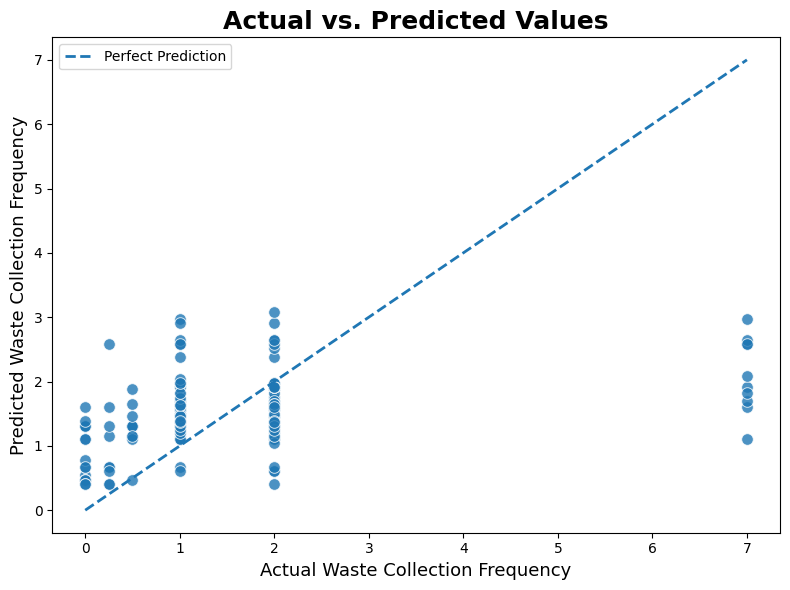

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=Y,
    y=Y_pred,
    s=70,
    alpha=0.8
)

# Perfect prediction line
plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Values",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Actual Waste Collection Frequency", fontsize=13)
plt.ylabel("Predicted Waste Collection Frequency", fontsize=13)

plt.legend()
plt.tight_layout()
plt.show()

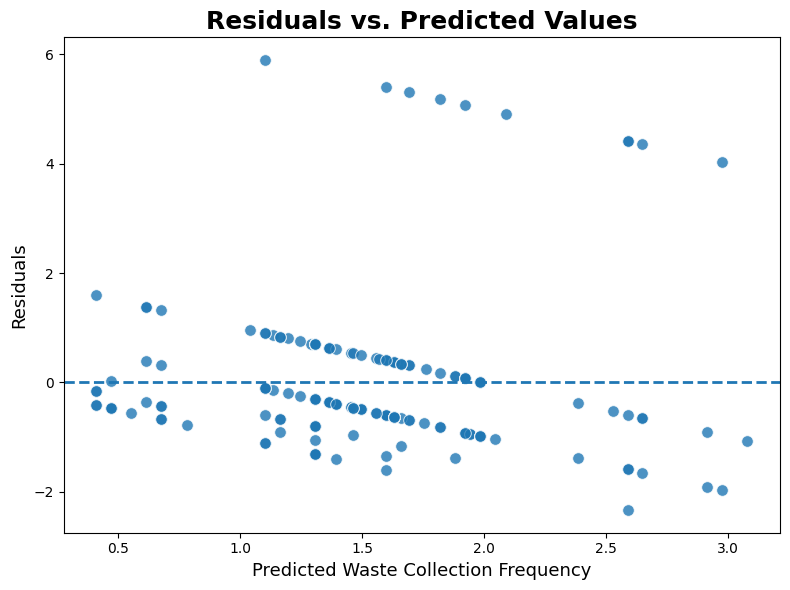

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=Y_pred,
    y=residuals,
    s=70,
    alpha=0.8
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residuals vs. Predicted Values",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Predicted Waste Collection Frequency", fontsize=13)
plt.ylabel("Residuals", fontsize=13)

plt.tight_layout()
plt.show()

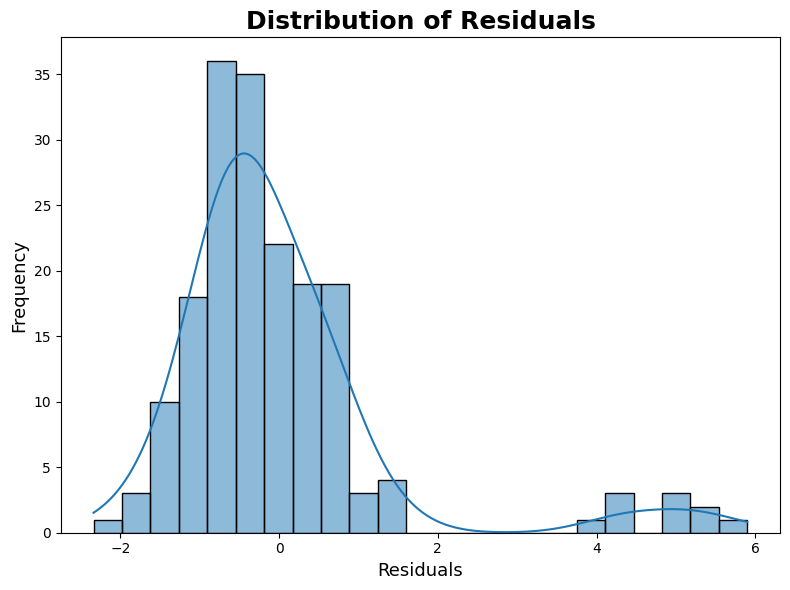

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Distribution of Residuals",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Residuals", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.tight_layout()
plt.show()

#***How does the number of people in a household affect the number of bags of each waste type generated per week?***

--- WASTE GENERATION: HOUSEHOLD SIZE IMPACT ---
Waste Category  Question 1: Avg Bags Created Per Week  Question 2: Extra Bags if +1 Person Joins
    Food Waste                               0.764865                                  -0.081078
  Garden Waste                               0.710811                                   0.004820
       Plastic                               0.556757                                  -0.001974
         Paper                               0.529730                                  -0.003024
       Coconut                               0.483784                                  -0.017350
     Packaging                               0.397297                                  -0.022618
         Other                               0.256757                                   0.014012
       Textile                               0.218919                                  -0.033804
         Metal                               0.202703                          

/tmp/ipykernel_2432/2521424360.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Question 1: Avg Bags Created Per Week', y='Waste Category', ax=ax1, palette='mako')
/tmp/ipykernel_2432/2521424360.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Question 2: Extra Bags if +1 Person Joins', y='Waste Category', ax=ax2, palette='flare')


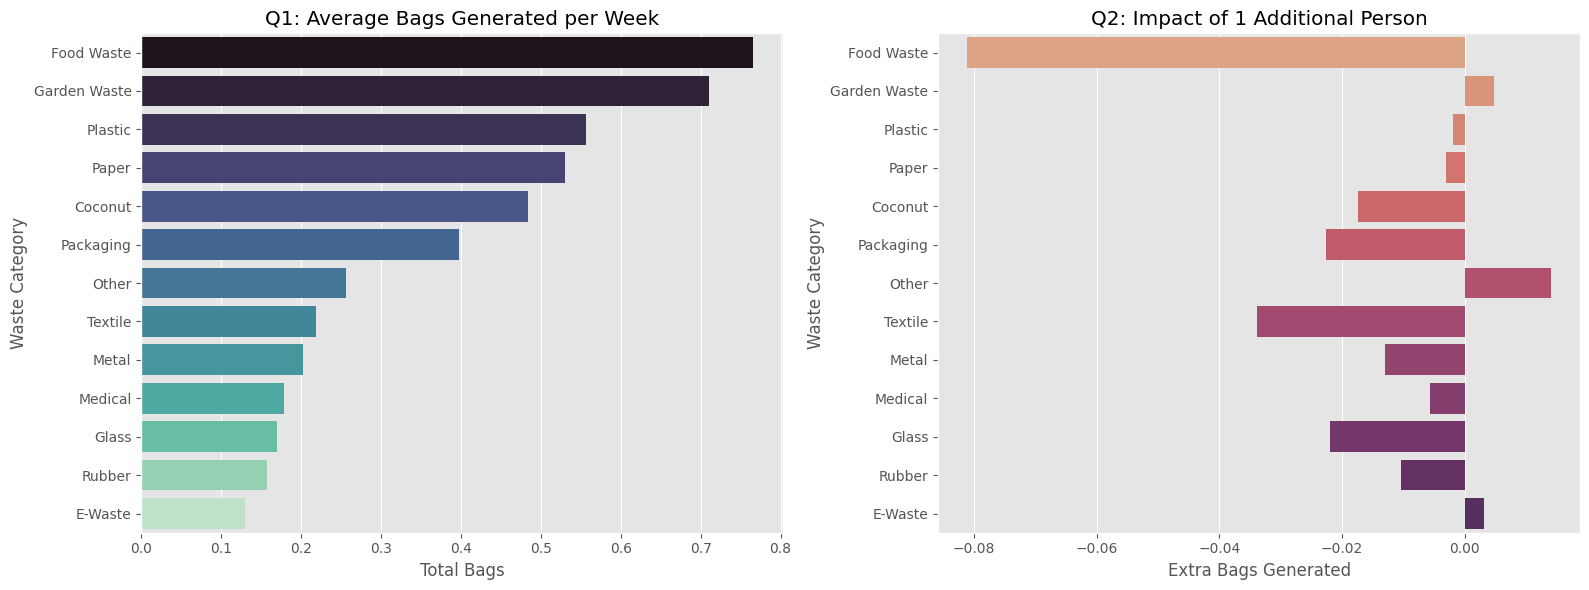

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data from the new file
df = pd.read_excel("Final_Cleaned_Waste_Survey_185.xlsx", sheet_name="Sheet1")

# 2. Data Cleaning Functions
def parse_fraction(val):
    if pd.isna(val): return 0
    val = str(val).strip()
    if val == '1/2': return 0.5
    try: return float(val)
    except ValueError: return 0

def map_people(val):
    if pd.isna(val): return np.nan
    if '1 - 2' in val: return 1.5
    if '3 - 4' in val: return 3.5
    if '5 - 6' in val: return 5.5
    if '7 - 8' in val: return 7.5
    if 'More than 8' in val: return 9.0
    return np.nan

df['Num_People'] = df['Q7. No. of People'].apply(map_people)

# 3. Identify Q12 columns (Waste Bags)
q12_cols = [col for col in df.columns if 'Q12' in col]
results = []

# 4. Loop through categories and run Regression
for col in q12_cols:
    cat_name = col.split('.')[1].replace('(bags)', '').strip()

    df[col] = df[col].apply(parse_fraction)

    # Isolate data and drop missing rows
    temp_df = df[[col, 'Num_People']].dropna()

    if len(temp_df) < 10:
        continue

    X = sm.add_constant(temp_df['Num_People'])
    y = temp_df[col]

    model = sm.OLS(y, X).fit()

    # Extract the answers to your two questions
    results.append({
        'Waste Category': cat_name,
        'Question 1: Avg Bags Created Per Week': y.mean(),
        'Question 2: Extra Bags if +1 Person Joins': model.params['Num_People']
    })

# 5. Display the answers in a clean table
results_df = pd.DataFrame(results).sort_values(by='Question 1: Avg Bags Created Per Week', ascending=False)
print("--- WASTE GENERATION: HOUSEHOLD SIZE IMPACT ---")
print(results_df.to_string(index=False))

# 6. Visualizations
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph for Question 1
sns.barplot(data=results_df, x='Question 1: Avg Bags Created Per Week', y='Waste Category', ax=ax1, palette='mako')
ax1.set_title('Q1: Average Bags Generated per Week')
ax1.set_xlabel('Total Bags')

# Graph for Question 2
sns.barplot(data=results_df, x='Question 2: Extra Bags if +1 Person Joins', y='Waste Category', ax=ax2, palette='flare')
ax2.set_title('Q2: Impact of 1 Additional Person')
ax2.set_xlabel('Extra Bags Generated')

plt.tight_layout()
plt.show()

# **Waste Generation and Monthly Waste-Management Expenditure**


**Research Question**

Does the amount of waste generated by a household affect its monthly waste-management expenditure?


**Objective**

The objective of this regression analysis is to investigate whether the amount of waste generated by a household is associated with its monthly expenditure on waste management.

**Independent Variable (X)**

Total weekly waste generated by the household, calculated by summing the quantities of all waste categories recorded in Q12.

**Dependent Variable (Y)**

Monthly waste-management expenditure obtained from Q22.

**Regression Model**

$$ \text{Monthly Expenditure} = a + b(\text{Total Weekly Waste}) $$

Where **a** represents the intercept and **b** represents the estimated change in monthly expenditure for each additional bag of weekly waste generated.

**Significance Level**

A significance level of α = 0.05 is used. If the p-value is less than 0.05, the relationship is considered statistically significant.

**R²**

R-squared is used to measure the proportion of variation in monthly waste-management expenditure that can be explained by total weekly waste generation.

**Important**

The monthly expenditure responses in Q22 are provided as expenditure ranges rather than exact amounts. Therefore, representative midpoint values are used for the expenditure ranges. The Rs. 5,000 and above category is represented by Rs. 5,000, so this category should be interpreted as an approximation.

In [ ]:
#Select the Waste-generation variables
waste_cols = [
    "Q12a. Food Waste (bags)",
    "Q12b. Garden Waste (bags)",
    "Q12c. Plastic (bags)",
    "Q12d. Paper (bags)",
    "Q12e. Glass (bags)",
    "Q12f. Metal (bags)",
    "Q12g. E-Waste (bags)",
    "Q12h. Textile (bags)",
    "Q12i. Rubber (bags)",
    "Q12j. Coconut (bags)",
    "Q12k. Packaging (bags)",
    "Q12l. Medical (bags)",
    "Q12m. Other (bags)"
]

In [ ]:
#Convert waste values into numbers
def parse_waste(value):

    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "1/2":
        return 0.5

    try:
        return float(value)

    except ValueError:
        return 0

for col in waste_cols:
    df[col] = df[col].apply(parse_waste)

In [ ]:
#Calculate total weekly waste
df["Total_Weekly_Waste"] = df[waste_cols].sum(axis=1)

#Check the result
print(df[
    ["Q12a. Food Waste (bags)",
     "Q12b. Garden Waste (bags)",
     "Q12c. Plastic (bags)",
     "Total_Weekly_Waste"]
].head(10))

   Q12a. Food Waste (bags)  Q12b. Garden Waste (bags)  Q12c. Plastic (bags)  \
0                      1.0                        0.0                   1.0   
1                      1.0                        2.0                   1.0   
2                      0.0                        0.0                   0.0   
3                      0.5                        2.0                   0.5   
4                      1.0                        2.0                   1.0   
5                      0.0                        0.0                   0.0   
6                      0.0                        0.0                   0.0   
7                      0.0                        0.0                   1.0   
8                      1.0                        0.5                   1.0   
9                      2.0                        2.0                   2.0   

   Total_Weekly_Waste  
0                 2.0  
1                 6.0  
2                 0.0  
3                 5.5  
4         

In [ ]:
#Convert monthly expenditure into numerical values
def expenditure_to_number(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "No expenditure":
        return 0

    elif value == "Less than Rs. 500":
        return 250

    elif value == "Rs. 500–999":
        return 749.5

    elif value == "Rs. 1,000–2,999":
        return 1999.5

    elif value == "Rs. 3,000–4,999":
        return 3999.5

    elif value == "Rs. 5,000 and above":
        return 5000

    else:
        return np.nan

#Conversion
df["Monthly_Expenditure"] = (df["Q22. Monthly Spend (Rs.)"]
                             .apply(expenditure_to_number))

In [ ]:
#Check the converted expenditure
print(
    df[
        ["Q22. Monthly Spend (Rs.)",
         "Monthly_Expenditure"]
    ].value_counts()
)

df[
    ["Q22. Monthly Spend (Rs.)",
     "Monthly_Expenditure"]
].head(20)

Q22. Monthly Spend (Rs.)  Monthly_Expenditure
No expenditure            0.0                    126
Less than Rs. 500         250.0                   37
Rs. 1,000–2,999           1999.5                   9
Rs. 500–999               749.5                    9
Rs. 3,000–4,999           3999.5                   3
Rs. 5,000 and above       5000.0                   1
Name: count, dtype: int64


,Q22. Monthly Spend (Rs.),Monthly_Expenditure
0,No expenditure,0.0
1,Less than Rs. 500,250.0
2,No expenditure,0.0
3,"Rs. 1,000–2,999",1999.5
4,No expenditure,0.0
5,No expenditure,0.0
6,Less than Rs. 500,250.0
7,No expenditure,0.0
8,No expenditure,0.0
9,"Rs. 1,000–2,999",1999.5


In [ ]:
#Create analysis_df
analysis_df = df[
    [
        "Total_Weekly_Waste",
        "Monthly_Expenditure"
    ]
].dropna()

#Check
print(analysis_df.head())
print("\nNumber of observations:", len(analysis_df))

   Total_Weekly_Waste  Monthly_Expenditure
0                 2.0                  0.0
1                 6.0                250.0
2                 0.0                  0.0
3                 5.5               1999.5
4                 7.0                  0.0

Number of observations: 185


In [ ]:
#Create the final regression dataset
print(
    df[
        ["Q22. Monthly Spend (Rs.)",
         "Monthly_Expenditure"]
    ].value_counts()
)

#Check how many responses remain
print("Number of observations:", len(analysis_df))

Q22. Monthly Spend (Rs.)  Monthly_Expenditure
No expenditure            0.0                    126
Less than Rs. 500         250.0                   37
Rs. 1,000–2,999           1999.5                   9
Rs. 500–999               749.5                    9
Rs. 3,000–4,999           3999.5                   3
Rs. 5,000 and above       5000.0                   1
Name: count, dtype: int64
Number of observations: 185


In [ ]:
#Descriptive statistics
print("\nDescriptive Statistics")
print("======================")

print(analysis_df.describe())


Descriptive Statistics
       Total_Weekly_Waste  Monthly_Expenditure
count          185.000000           185.000000
mean             4.756757           275.618919
std              6.722591           745.583315
min              0.000000             0.000000
25%              0.000000             0.000000
50%              3.000000             0.000000
75%              7.000000           250.000000
max             32.000000          5000.000000


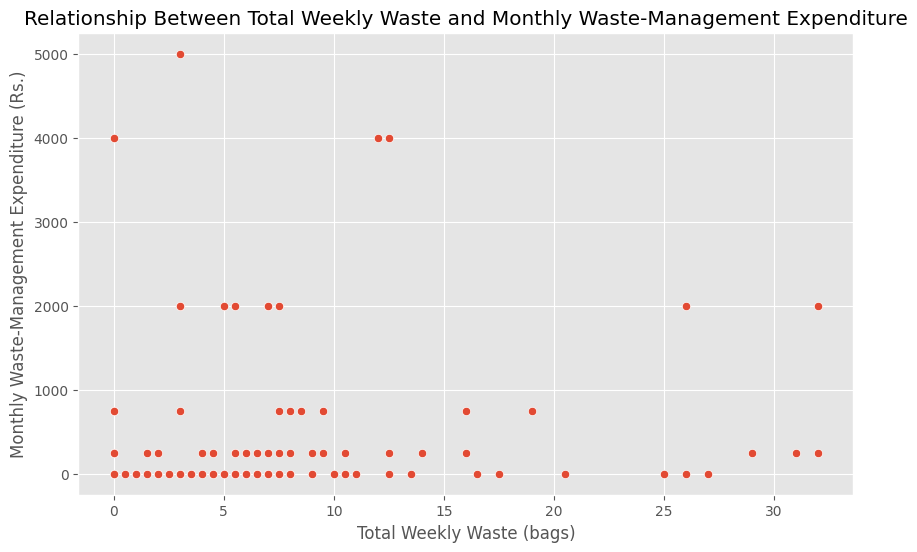

In [ ]:
#Create a scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df,
    x="Total_Weekly_Waste",
    y="Monthly_Expenditure"
)

plt.title(
    "Relationship Between Total Weekly Waste and Monthly Waste-Management Expenditure"
)

plt.xlabel("Total Weekly Waste (bags)")
plt.ylabel("Monthly Waste-Management Expenditure (Rs.)")

plt.grid(True)
plt.show()

In [ ]:
#Create the regression model
# Independent variable
X = analysis_df["Total_Weekly_Waste"]

# Dependent variable
y = analysis_df["Monthly_Expenditure"]

# Add constant/intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Monthly_Expenditure   R-squared:                       0.036
Model:                             OLS   Adj. R-squared:                  0.031
Method:                  Least Squares   F-statistic:                     6.885
Date:                 Wed, 30 Sep 2026   Prob (F-statistic):            0.00943
Time:                         17:53:05   Log-Likelihood:                -1482.2
No. Observations:                  185   AIC:                             2968.
Df Residuals:                      183   BIC:                             2975.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                175.1

In [ ]:
#Extract the important regression results
intercept = model.params["const"]

coefficient = model.params[
    "Total_Weekly_Waste"
]

p_value = model.pvalues[
    "Total_Weekly_Waste"
]

r_squared = model.rsquared

print("\n==========================================")
print("REGRESSION RESULTS")
print("==========================================")

print(f"Intercept: {intercept:.2f}")

print(
    f"Coefficient: {coefficient:.2f}"
)

print(
    f"P-value: {p_value:.4f}"
)

print(
    f"R-squared: {r_squared:.4f}"
)


REGRESSION RESULTS
Intercept: 175.16
Coefficient: 21.12
P-value: 0.0094
R-squared: 0.0363


In [ ]:
#Display the regression equation
print("\nRegression Equation:")
print(
    f"Monthly Expenditure = "
    f"{intercept:.2f} + "
    f"{coefficient:.2f} × Total Weekly Waste"
)


Regression Equation:
Monthly Expenditure = 175.16 + 21.12 × Total Weekly Waste


In [ ]:
#Test statistical significance
alpha = 0.05

print("\nStatistical Significance")

if p_value < alpha:
    print(
        "The relationship is statistically significant "
        "(p < 0.05)."
    )
else:
    print(
        "The relationship is not statistically significant "
        "(p >= 0.05)."
    )


Statistical Significance
The relationship is statistically significant (p < 0.05).


In [ ]:
#Interpret the coefficient
print("\nCoefficient Interpretation:")

if coefficient > 0:

    print(
        f"For every additional 1 bag of weekly waste, "
        f"monthly expenditure is estimated to increase "
        f"by approximately Rs. {coefficient:.2f}."
    )

elif coefficient < 0:

    print(
        f"For every additional 1 bag of weekly waste, "
        f"monthly expenditure is estimated to decrease "
        f"by approximately Rs. {abs(coefficient):.2f}."
    )

else:

    print(
        "The estimated change in expenditure is approximately zero."
    )


Coefficient Interpretation:
For every additional 1 bag of weekly waste, monthly expenditure is estimated to increase by approximately Rs. 21.12.


In [ ]:
#Interpret R²
print("\nR-squared Interpretation:")

print(
    f"R-squared = {r_squared:.4f}"
)

print(
    f"Approximately {r_squared * 100:.2f}% "
    "of the variation in monthly expenditure "
    "is explained by total weekly waste."
)


R-squared Interpretation:
R-squared = 0.0363
Approximately 3.63% of the variation in monthly expenditure is explained by total weekly waste.


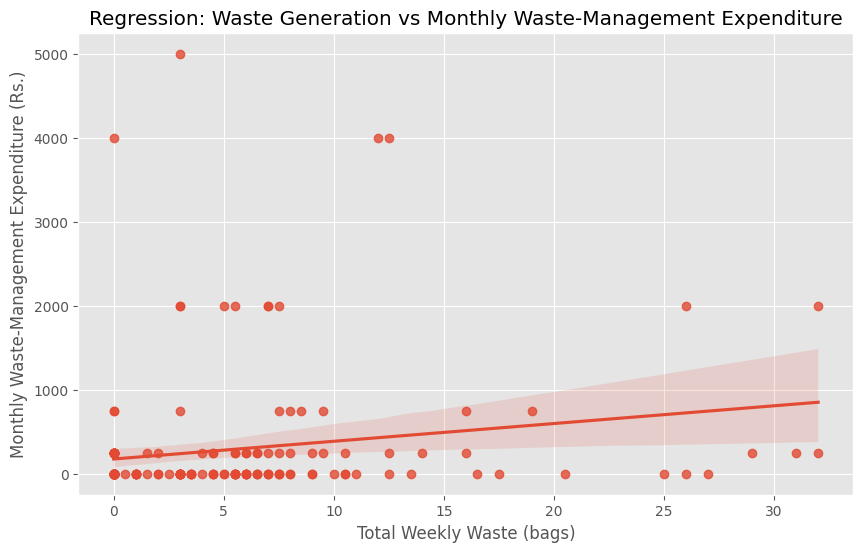

In [ ]:
#Plot the regression line
plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df,
    x="Total_Weekly_Waste",
    y="Monthly_Expenditure",
    ci=95
)

plt.title(
    "Regression: Waste Generation vs Monthly Waste-Management Expenditure"
)

plt.xlabel("Total Weekly Waste (bags)")

plt.ylabel(
    "Monthly Waste-Management Expenditure (Rs.)"
)

plt.grid(True)

plt.show()

In [ ]:
#Predict expenditure for 5, 10 and 15 bags per week
new_waste = pd.DataFrame({
    "const": 1,
    "Total_Weekly_Waste": [5, 10, 15]
})

predictions = model.predict(new_waste)

prediction_table = pd.DataFrame({
    "Weekly Waste (bags)": [5, 10, 15],
    "Predicted Monthly Expenditure (Rs.)": predictions
})

print(prediction_table)

   Weekly Waste (bags)  Predicted Monthly Expenditure (Rs.)
0                    5                           280.755773
1                   10                           386.346663
2                   15                           491.937554


In [ ]:
#Summary
print("\n")
print("==============================================")
print("FINAL REGRESSION ANALYSIS SUMMARY")
print("==============================================")

print(
    "Research Question:"
)

print(
    "Does the amount of waste generated by a "
    "household affect its monthly waste-management expenditure?"
)

print("\nRegression Model:")
print(
    f"Monthly Expenditure = "
    f"{intercept:.2f} + "
    f"{coefficient:.2f} × Total Weekly Waste"
)

print(
    f"\nR-squared: {r_squared:.4f}"
)

print(
    f"P-value: {p_value:.4f}"
)

if p_value < 0.05:
    print(
        "\nConclusion: There is statistically significant "
        "evidence of a linear relationship between total "
        "weekly waste generation and monthly waste-management "
        "expenditure."
    )
else:
    print(
        "\nConclusion: There is not enough statistical evidence "
        "to conclude that total weekly waste generation has a "
        "linear relationship with monthly waste-management "
        "expenditure."
    )



FINAL REGRESSION ANALYSIS SUMMARY
Research Question:
Does the amount of waste generated by a household affect its monthly waste-management expenditure?

Regression Model:
Monthly Expenditure = 175.16 + 21.12 × Total Weekly Waste

R-squared: 0.0363
P-value: 0.0094

Conclusion: There is statistically significant evidence of a linear relationship between total weekly waste generation and monthly waste-management expenditure.


In [ ]:
# Predicted values
y_pred = model.predict(X)

# Residuals (mistakes = actual - predicted)
residuals = y - y_pred

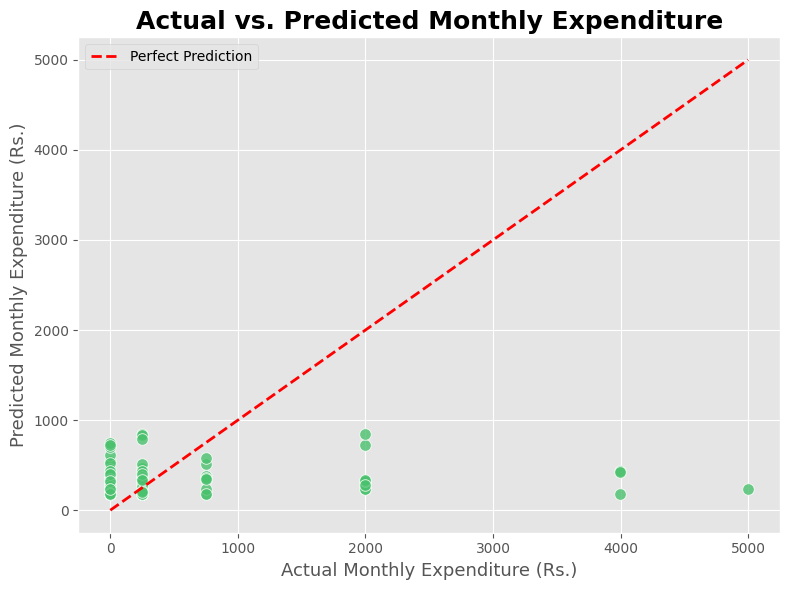

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y,
    y=y_pred,
    color=sns.color_palette("viridis")[4],
    s=70,
    alpha=0.8
)

# Perfect prediction line
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs. Predicted Monthly Expenditure",
          fontsize=18,
          weight="bold")
plt.xlabel("Actual Monthly Expenditure (Rs.)", fontsize=13)
plt.ylabel("Predicted Monthly Expenditure (Rs.)", fontsize=13)
plt.legend()

plt.tight_layout()
plt.show()

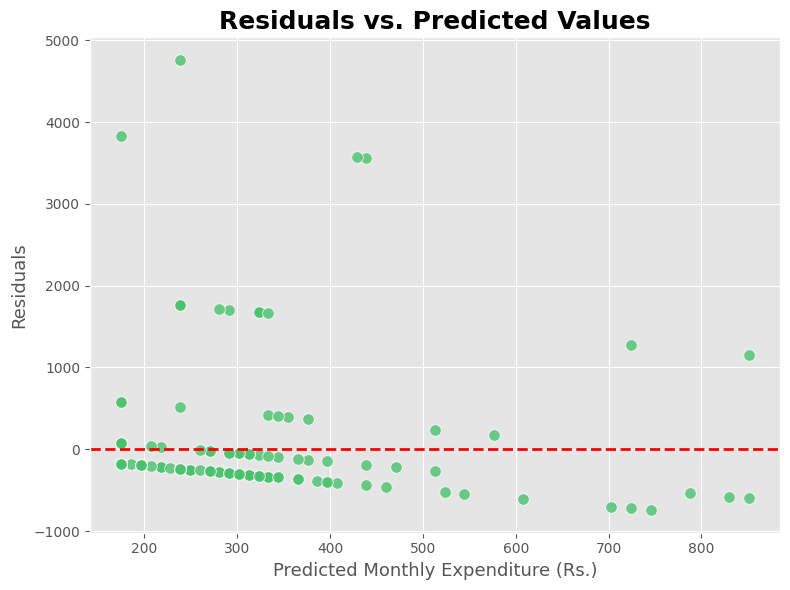

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    color=sns.color_palette("viridis")[4],
    s=70,
    alpha=0.8
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residuals vs. Predicted Values",
          fontsize=18,
          weight="bold")
plt.xlabel("Predicted Monthly Expenditure (Rs.)", fontsize=13)
plt.ylabel("Residuals", fontsize=13)

plt.tight_layout()
plt.show()

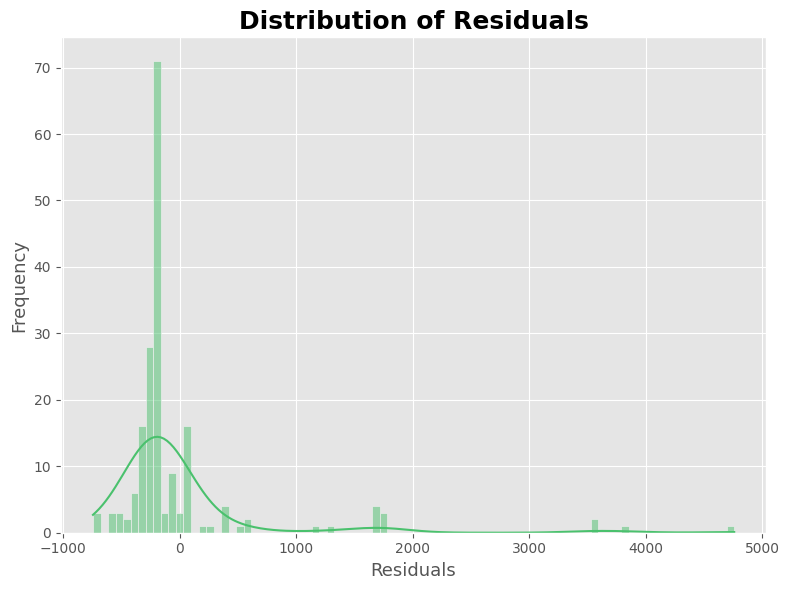

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True,
    color=sns.color_palette("viridis")[4]
)

plt.title("Distribution of Residuals",
          fontsize=18,
          weight="bold")
plt.xlabel("Residuals", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.tight_layout()
plt.show()

#***What factors influence the waste disposal methods adopted by households?***

###**Objective**

The objective of this analysis is to identify the factors associated with whether a household uses the municipal waste collection service.

A binary logistic regression model will be used because the dependent variable has two possible outcomes:

- 1 = Uses Municipal Collection
- 0 = Does Not Use Municipal Collection

###**Variables Used in the Regression**

**Dependent Variable**

Q21. Disposal Method

Q21 contains multiple possible disposal methods. For logistic regression, it will be converted into a binary variable:

- 1 = Uses Municipal Collection
- 0 = Does Not Use Municipal Collection

**Independent Variables**

The following variables will be used as predictors:

1. Q1. Age
2. Q5. Area Type
3. Q7. No. of People
4. Q9. Waste Storage Method
5. Q19. Distance to Collection Point
6. Q20. Collection Frequency
7. Q15. Recycle Waste?
8. Q18. Monthly Income

In [ ]:
# Load data and clean Q21

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Upload Final_Cleaned_Waste_Survey_185.xlsx to Colab first (left sidebar > Files)
df = pd.read_excel('Final_Cleaned_Waste_Survey_185.xlsx')
print("Shape:", df.shape)

# ---- Clean Q21 ----
# Remove extra spaces; the answers contain English + Sinhala text, so we search the English keywords
df['Disposal_Clean'] = df['Q21. Disposal Method'].astype(str).str.strip()

# How many households mention each method (multiple answers allowed)
methods = {
    'Municipal collection': 'Municipal|municipal',
    'Private collection': 'Private',
    'Composting': 'Composting',
    'Burning': 'Burning',
    'Burying': 'Burying',
    'Dumping in open areas': 'Dumping',
    'Road/street side': 'road or street',
}
summary = pd.Series({k: df['Disposal_Clean'].str.contains(v, na=False).sum() for k, v in methods.items()})
print("\nHouseholds mentioning each disposal method (multiple answers allowed):")
print(summary.sort_values(ascending=False))

Shape: (185, 49)

Households mentioning each disposal method (multiple answers allowed):
Municipal collection     112
Composting                67
Burning                   56
Burying                   35
Private collection        12
Dumping in open areas      5
Road/street side           2
dtype: int64


In [ ]:
# Binary variable for the main disposal method

# Municipal collection is the most common method, so it is the main disposal method.
# This also catches the typed answer "Hand over to municipal collection services".
df['Municipal_Use'] = df['Disposal_Clean'].str.contains('municipal', case=False, na=False).astype(int)

print(df['Municipal_Use'].value_counts())
print("\nPercentage:")
print((df['Municipal_Use'].value_counts(normalize=True) * 100).round(1))

Municipal_Use
1    112
0     73
Name: count, dtype: int64

Percentage:
Municipal_Use
1    60.5
0    39.5
Name: proportion, dtype: float64


In [ ]:
# Convert independent variables to numeric/dummy

# --- Distance check: perfect separation problem ---
print(pd.crosstab(df['Q19. Distance to Collection Point'], df['Municipal_Use']))
# All 23 "No collection point available" households have Municipal_Use = 0.
# Municipal collection is impossible for them, and this perfect separation makes
# logistic regression fail to converge. So these rows are excluded from the model.

d = df[df['Q19. Distance to Collection Point'] != 'No collection point available'].copy()
print("\nRows after removing 'No collection point available':", len(d))

# --- Numeric conversions ---
d['People_Number'] = d['Q7. No. of People'].map({
    '1 - 2 persons': 1.5, '3 - 4 persons': 3.5, '5 - 6 persons': 5.5,
    '7 - 8 persons': 7.5, 'More than 8 persons': 9})

d['Land_Size_Perches'] = d['Q8. Land Size'].map({
    'Less than 10 perches (<250 m²)': 5,
    '10–19 perches (250–499 m²)': 14.5,
    '20–39 perches (500–999 m²)': 29.5,
    '40–79 perches (1000–1999 m²)': 59.5,
    '80 perches and above (>2000 m²)': 100})

d['Distance_Level'] = d['Q19. Distance to Collection Point'].map({
    'Less than 100 m': 1, '100–499 m': 2, '500–999 m': 3,
    '1–2 km': 4, 'More than 2 km': 5})

d['Separate_Recyclables'] = (d['Q14. Separate Recyclables?'] == 'Yes').astype(int)

# --- Area type: keep the English word only, then create dummies (Rural = reference) ---
d['Area_Type'] = d['Q5. Area Type'].str.split(' ').str[0]
print(d['Area_Type'].value_counts())

Municipal_Use                       0   1
Q19. Distance to Collection Point        
100–499 m                           5  13
1–2 km                             15  31
500–999 m                           3   6
Less than 100 m                     5  13
More than 2 km                     22  49
No collection point available      23   0

Rows after removing 'No collection point available': 162
Area_Type
Semi-urban    71
Urban         60
Rural         31
Name: count, dtype: int64


In [ ]:
# Create the regression dataset

reg_df = d[['Municipal_Use', 'People_Number', 'Land_Size_Perches',
            'Distance_Level', 'Separate_Recyclables', 'Area_Type']].copy()

# Dummy variables (drop_first=True makes Rural the reference group)
reg_df = pd.get_dummies(reg_df, columns=['Area_Type'], drop_first=True, dtype=int)

# Check for missing values
print("Missing values:\n", reg_df.isnull().sum())
reg_df = reg_df.dropna()

print("\nFinal regression dataset shape:", reg_df.shape)
reg_df.head()

Missing values:
 Municipal_Use           0
People_Number           0
Land_Size_Perches       0
Distance_Level          0
Separate_Recyclables    0
Area_Type_Semi-urban    0
Area_Type_Urban         0
dtype: int64

Final regression dataset shape: (162, 7)


,Municipal_Use,People_Number,Land_Size_Perches,Distance_Level,Separate_Recyclables,Area_Type_Semi-urban,Area_Type_Urban
0,1,5.5,14.5,5,1,0,1
1,1,5.5,14.5,5,1,1,0
2,1,3.5,5.0,5,1,1,0
4,0,9.0,29.5,4,1,0,0
5,0,3.5,14.5,4,1,1,0


In [ ]:
# Descriptive statistics

print("=== Numeric variables ===")
print(reg_df[['People_Number', 'Land_Size_Perches', 'Distance_Level']].describe().round(2))

print("\n=== Mean of predictors by municipal use ===")
print(reg_df.groupby('Municipal_Use').mean().round(2).T)

print("\n=== Municipal use by Area Type ===")
print(pd.crosstab(d['Area_Type'], d['Municipal_Use'], margins=True))
print((pd.crosstab(d['Area_Type'], d['Municipal_Use'], normalize='index') * 100).round(1))

# Multicollinearity check (VIF; values below 5 are fine)
X_vif = sm.add_constant(reg_df.drop(columns='Municipal_Use').astype(float))
vif = pd.DataFrame({
    'Variable': X_vif.columns[1:],
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
}).round(2)
print("\n=== VIF ===")
print(vif)

=== Numeric variables ===
       People_Number  Land_Size_Perches  Distance_Level
count         162.00             162.00          162.00
mean            4.23              25.43            3.83
std             1.34              24.88            1.39
min             1.50               5.00            1.00
25%             3.50              14.50            3.00
50%             3.50              14.50            4.00
75%             5.50              29.50            5.00
max             9.00             100.00            5.00

=== Mean of predictors by municipal use ===
Municipal_Use             0      1
People_Number          4.05   4.31
Land_Size_Perches     32.02  22.49
Distance_Level         3.88   3.80
Separate_Recyclables   0.82   0.94
Area_Type_Semi-urban   0.48   0.42
Area_Type_Urban        0.18   0.46

=== Municipal use by Area Type ===
Municipal_Use   0    1  All
Area_Type                  
Rural          17   14   31
Semi-urban     24   47   71
Urban           9   51   60
All 

In [ ]:
# Run logistic regression

y = reg_df['Municipal_Use']
X = sm.add_constant(reg_df.drop(columns='Municipal_Use').astype(float))

logit_model = sm.Logit(y, X).fit(disp=0)
print("Model converged:", logit_model.mle_retvals['converged'])

Model converged: True


In [ ]:
# Display the regression results

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:          Municipal_Use   No. Observations:                  162
Model:                          Logit   Df Residuals:                      155
Method:                           MLE   Df Model:                            6
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                  0.1179
Time:                        03:26:25   Log-Likelihood:                -88.313
converged:                       True   LL-Null:                       -100.12
Covariance Type:            nonrobust   LLR p-value:                 0.0006162
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.2369      1.072     -1.154      0.249      -3.338       0.864
People_Number            0.0889      0.148      0.600      0.548      -0.201       0.379
Land_Size_Pe

In [ ]:
# Odds ratios

odds = pd.DataFrame({
    'Coefficient (B)': logit_model.params,
    'Odds Ratio': np.exp(logit_model.params),
    'OR 95% CI Lower': np.exp(logit_model.conf_int()[0]),
    'OR 95% CI Upper': np.exp(logit_model.conf_int()[1]),
    'P-value': logit_model.pvalues
}).round(4)
odds

,Coefficient (B),Odds Ratio,OR 95% CI Lower,OR 95% CI Upper,P-value
const,-1.2369,0.2903,0.0355,2.3737,0.2486
People_Number,0.0889,1.0930,0.8177,1.4610,0.5482
Land_Size_Perches,-0.0127,0.9874,0.9738,1.0012,0.0725
Distance_Level,0.0213,1.0215,0.7763,1.3442,0.8792
Separate_Recyclables,1.0775,2.9374,0.9463,9.1181,0.0623
Area_Type_Semi-urban,0.8831,2.4185,0.9785,5.9779,0.0558
Area_Type_Urban,1.8194,6.1680,2.1650,17.5721,0.0007


In [ ]:
# Check p-values

alpha = 0.05
pv = logit_model.pvalues.drop('const')
pval_table = pd.DataFrame({
    'P-value': pv.round(4),
    'Significant at 5%?': np.where(pv < alpha, 'Yes', 'No'),
    'Significant at 10%?': np.where(pv < 0.10, 'Yes', 'No')
})
print(pval_table)

# Overall model significance (Likelihood Ratio test)
print(f"\nLR chi-square = {logit_model.llr:.3f}, df = {int(logit_model.df_model)}, "
      f"p-value = {logit_model.llr_pvalue:.5f}")
print("Overall model is", "SIGNIFICANT" if logit_model.llr_pvalue < alpha else "NOT significant", "at 5%")

                      P-value Significant at 5%? Significant at 10%?
People_Number          0.5482                 No                  No
Land_Size_Perches      0.0725                 No                 Yes
Distance_Level         0.8792                 No                  No
Separate_Recyclables   0.0623                 No                 Yes
Area_Type_Semi-urban   0.0558                 No                 Yes
Area_Type_Urban        0.0007                Yes                 Yes

LR chi-square = 23.609, df = 6, p-value = 0.00062
Overall model is SIGNIFICANT at 5%


In [ ]:
# Evaluate the model

pred_prob = logit_model.predict(X)
pred_class = (pred_prob >= 0.5).astype(int)

print(f"McFadden Pseudo R²: {logit_model.prsquared:.4f}")
print(f"AIC: {logit_model.aic:.2f}   BIC: {logit_model.bic:.2f}")
print(f"Accuracy: {accuracy_score(y, pred_class):.4f}")
print(f"AUC (ROC): {roc_auc_score(y, pred_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y, pred_class))

print("\nClassification Report:")
print(classification_report(y, pred_class, target_names=['Not municipal (0)', 'Municipal (1)']))

McFadden Pseudo R²: 0.1179
AIC: 190.63   BIC: 212.24
Accuracy: 0.7160
AUC (ROC): 0.7314

Confusion Matrix:
[[ 16  34]
 [ 12 100]]

Classification Report:
                   precision    recall  f1-score   support

Not municipal (0)       0.57      0.32      0.41        50
    Municipal (1)       0.75      0.89      0.81       112

         accuracy                           0.72       162
        macro avg       0.66      0.61      0.61       162
     weighted avg       0.69      0.72      0.69       162



/tmp/ipykernel_11517/3500223876.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Municipal_Use', data=reg_df, ax=axes[0, 0], palette='Set2')


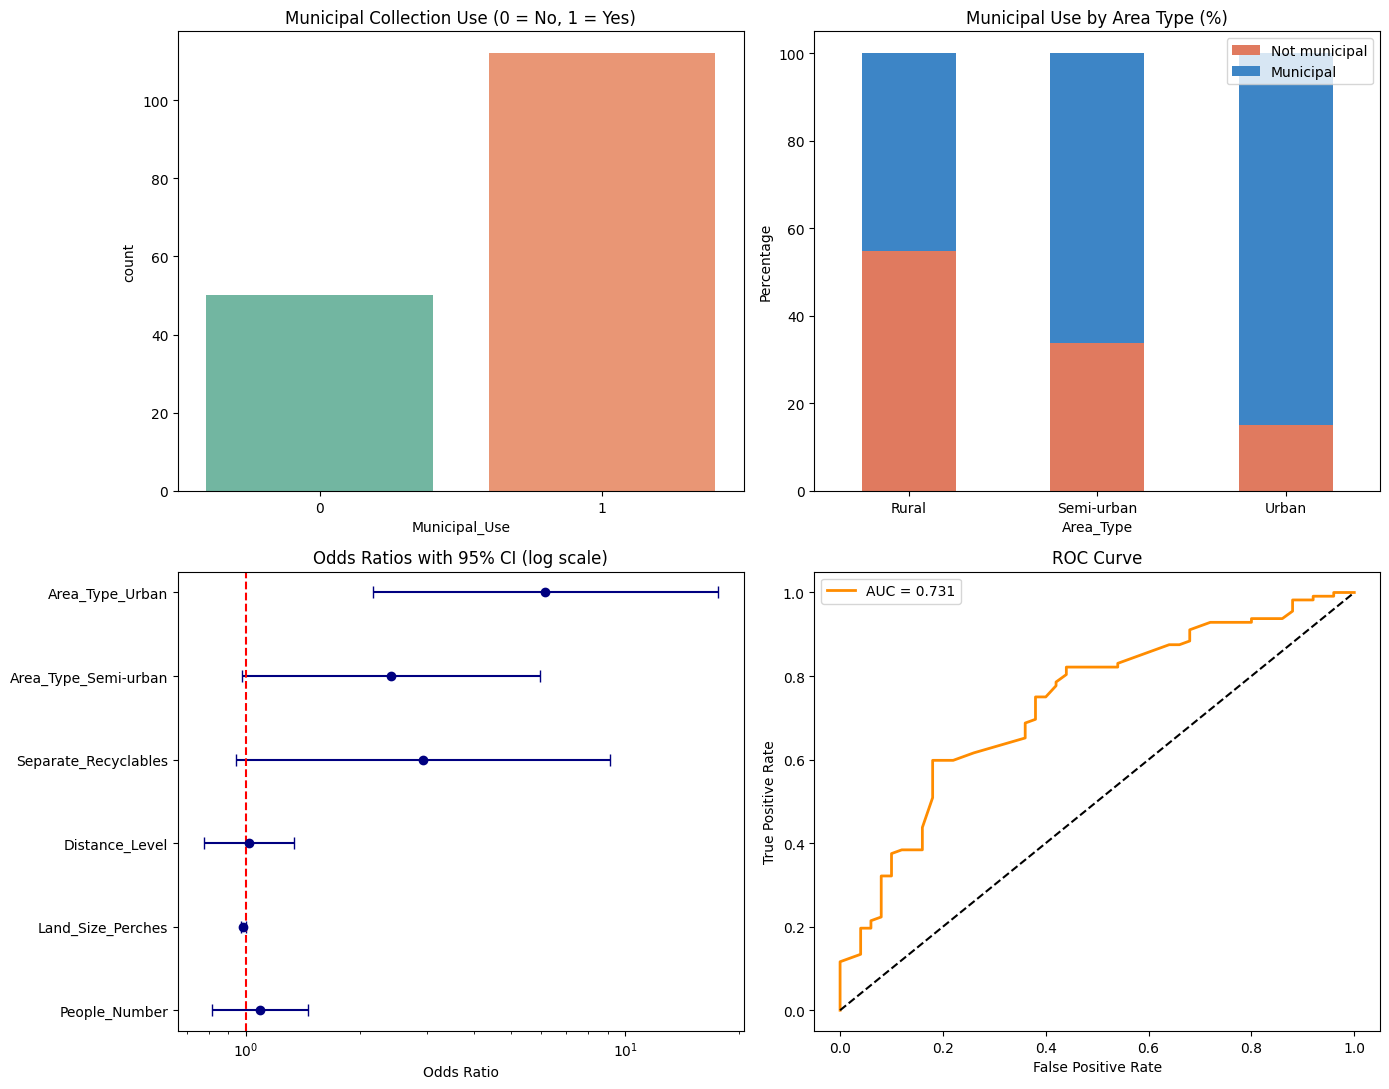

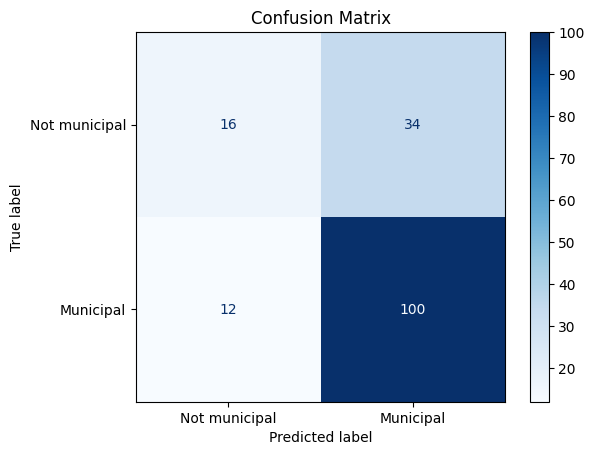

In [ ]:
# Create graphs

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Distribution of the dependent variable
sns.countplot(x='Municipal_Use', data=reg_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Municipal Collection Use (0 = No, 1 = Yes)')
axes[0, 0].set_xlabel('Municipal_Use')

# 2. Municipal use by area type
pd.crosstab(d['Area_Type'], d['Municipal_Use'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0, 1], color=['#e07a5f', '#3d85c6'])
axes[0, 1].set_title('Municipal Use by Area Type (%)')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(['Not municipal', 'Municipal'])

# 3. Odds ratio plot with 95% CI
orp = odds.drop('const')
axes[1, 0].errorbar(orp['Odds Ratio'], range(len(orp)),
                    xerr=[orp['Odds Ratio'] - orp['OR 95% CI Lower'],
                          orp['OR 95% CI Upper'] - orp['Odds Ratio']],
                    fmt='o', color='navy', capsize=4)
axes[1, 0].axvline(1, color='red', linestyle='--')
axes[1, 0].set_yticks(range(len(orp)))
axes[1, 0].set_yticklabels(orp.index)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Odds Ratios with 95% CI (log scale)')
axes[1, 0].set_xlabel('Odds Ratio')

# 4. ROC curve
fpr, tpr, _ = roc_curve(y, pred_prob)
axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y, pred_prob):.3f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Confusion matrix heatmap
ConfusionMatrixDisplay(confusion_matrix(y, pred_class),
                       display_labels=['Not municipal', 'Municipal']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Regression Summary

sig = pval_table[pval_table['Significant at 5%?'] == 'Yes'].index.tolist()

print("=" * 65)
print("                 REGRESSION SUMMARY")
print("=" * 65)
print("Model                : Binary Logistic Regression")
print("Dependent variable   : Municipal_Use (1 = uses municipal collection)")
print(f"Sample size          : {len(reg_df)} households")
print(f"Overall model (LR)   : chi2 = {logit_model.llr:.2f}, p = {logit_model.llr_pvalue:.5f}")
print(f"McFadden Pseudo R²   : {logit_model.prsquared:.4f}")
print(f"Accuracy             : {accuracy_score(y, pred_class)*100:.1f}%")
print(f"AUC                  : {roc_auc_score(y, pred_prob):.3f}")
print(f"Significant at 5%    : {sig if sig else 'None'}")
print("-" * 65)
print(odds[['Odds Ratio', 'OR 95% CI Lower', 'OR 95% CI Upper', 'P-value']].drop('const'))
print("=" * 65)

                 REGRESSION SUMMARY
Model                : Binary Logistic Regression
Dependent variable   : Municipal_Use (1 = uses municipal collection)
Sample size          : 162 households
Overall model (LR)   : chi2 = 23.61, p = 0.00062
McFadden Pseudo R²   : 0.1179
Accuracy             : 71.6%
AUC                  : 0.731
Significant at 5%    : ['Area_Type_Urban']
-----------------------------------------------------------------
                      Odds Ratio  OR 95% CI Lower  OR 95% CI Upper  P-value
People_Number             1.0930           0.8177           1.4610   0.5482
Land_Size_Perches         0.9874           0.9738           1.0012   0.0725
Distance_Level            1.0215           0.7763           1.3442   0.8792
Separate_Recyclables      2.9374           0.9463           9.1181   0.0623
Area_Type_Semi-urban      2.4185           0.9785           5.9779   0.0558
Area_Type_Urban           6.1680           2.1650          17.5721   0.0007
